# ***Previsão da Demanda de Mão de Obra no Setor Portuário com Base na Movimentação de TEUs e Análise Temporal***



**INTEGRANTES:** Luigi Leone e Manuela Silva


---



 ftp://ftp.mtps.gov.br/pdet/microdados/

## Limpeza e Coleta de Dados

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv(
    'CAGEDMOV202604.txt',
    sep=';',
    encoding='utf-8', #utf-8 para 2020 adiante, latin1 para caged antigo
    dtype=str,           # evita conversões automáticas
    skipinitialspace=True,  # remove espaços extras
    on_bad_lines='skip', # pula linhas corrompidas
    low_memory=False     # lê o arquivo inteiro de uma vez
)

# remover linhas completamente vazias
df = df.dropna(how='all')

# remover espaços nos nomes das colunas
df.columns = df.columns.str.strip()

print(df.shape)

(4451422, 28)


In [ ]:
df.head(2)

,competênciamov,região,uf,município,seção,subclasse,saldomovimentação,cbo2002ocupação,categoria,graudeinstrução,...,indtrabintermitente,indtrabparcial,salário,tamestabjan,indicadoraprendiz,origemdainformação,competênciadec,indicadordeforadoprazo,unidadesaláriocódigo,valorsaláriofixo
0,202604,3,35,351905,A,111302,1,622020,105,4,...,0,0,"1654,62",9,0,1,202604,0,5,"1654,62"
1,202604,3,35,355720,Q,8610101,1,422105,101,7,...,0,0,"1665,10",10,0,1,202604,0,5,"1665,10"


In [ ]:
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

In [ ]:
"""df_2019 = df.rename(columns={
    'Município': 'município',
    'CNAE 2.0 Subclas': 'subclasse',
    'CBO 2002 Ocupação': 'cbo2002ocupação',
    'Salário Mensal': 'salário',
    'Qtd Hora Contrat': 'horascontratuais',
    'Saldo Mov': 'saldomovimentação'
})"""

#processo de mapear os nomes das colunas para renomear, apenas para filtrar dados do caged antigo

In [ ]:
municipio = ['354850']
subclasses = [
    '5231101', '5231102', '5212500',
    '5229001', '5229002', '5030101',
    '5030102', '5250801', '5250802', '5250803'
]

cbos = [
    '414105', '414110', '717405', '717410',
    '717415', '717420', '717425', '717430',
    '717435', '314105', '782305', '782310',
    '782315', '423105'
]

df_filtrado = df[
    (df['município'].isin(municipio)) &
    (
        (df['subclasse'].isin(subclasses)) |
        (df['cbo2002ocupação'].isin(cbos))
    )
]

#município, subclasse e cbo2002ocupação para 2020 adiante, Município, CNAE 2.0 Subclas e CBO 2002 Ocupação para caged antigo
#substituir nome do dataframe para df_2019 no caso de filtrar o caged antigo

In [ ]:
print(df_filtrado.head(3))

      competênciamov região  uf município seção subclasse saldomovimentação  \
9593          202604      3  35    354850     H   5250801                -1   
14264         202604      3  35    354850     G   4744099                 1   
15401         202604      3  35    354850     H   5231102                 1   

      cbo2002ocupação categoria graudeinstrução  ... indtrabintermitente  \
9593           411045       101               7  ...                   0   
14264          782310       101               7  ...                   0   
15401          351605       101               7  ...                   0   

      indtrabparcial  salário tamestabjan indicadoraprendiz  \
9593               0  5075,37           7                 0   
14264              0  2870,86           2                 0   
15401              0  5000,00           7                 0   

      origemdainformação competênciadec indicadordeforadoprazo  \
9593                   1         202604                    

In [ ]:
len(df_filtrado)

923

In [ ]:
df_filtrado.loc[:, 'saldomovimentação'] = df_filtrado['saldomovimentação'].astype(int)
df_filtrado.loc[:, 'horascontratuais'] = df_filtrado['horascontratuais'].astype(str).str.strip().str.replace(',', '.', regex=False).astype(float)
df_filtrado.loc[:, 'salário'] = df_filtrado['salário'].astype(str).str.strip().str.replace(',', '.', regex=False).astype(float)

In [ ]:
print(f"Salário Médio: {df_filtrado['salário'].mean():.2f}")
print(f"Horas Médias: {df_filtrado['horascontratuais'].mean():.2f}")
print(f"Saldo: {df_filtrado['saldomovimentação'].sum()}")

Salário Médio: 3681.84
Horas Médias: 42.46
Saldo: -221


## Análise Exploratória de Dados

In [ ]:
#Importação
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
df = pd.read_excel("dadostcc2.xlsx")

In [ ]:
display(df.head(5))

,ano,mês,covid,salario_media,horas_media,teu,saldo
0,2016,1,0,2116.05,42.29,81220,34
1,2016,2,0,2295.56,41.13,73466,-105
2,2016,3,0,1652.68,42.72,81463,-188
3,2016,4,0,1689.02,43.07,72511,-377
4,2016,5,0,2233.69,42.75,89188,-293


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ano            124 non-null    int64  
 1   mês            124 non-null    int64  
 2   covid          124 non-null    int64  
 3   salario_media  124 non-null    float64
 4   horas_media    124 non-null    float64
 5   teu            124 non-null    int64  
 6   saldo          124 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 6.9 KB


In [ ]:
df[['salario_media','horas_media','teu','saldo']].describe()

,salario_media,horas_media,teu,saldo
count,124.000000,124.000000,124.000000,124.000000
mean,2912.061694,42.102742,91827.145161,16.379032
std,541.736286,0.691276,14994.364889,138.045980
min,1533.980000,39.840000,49344.000000,-445.000000
25%,2566.730000,41.647500,82000.000000,-39.250000
50%,2872.530000,42.180000,89936.500000,28.000000
75%,3261.620000,42.465000,100499.750000,83.500000
max,4699.760000,45.780000,128566.000000,329.000000


In [ ]:
print(df.groupby('covid')[['teu', 'saldo', 'salario_media', 'horas_media']].describe())

        teu                                                            \
      count           mean           std      min       25%       50%   
covid                                                                   
0      50.0   85581.420000   9798.084126  72511.0  78353.75   84313.5   
1      38.0   86082.842105  12910.020660  49344.0  81855.25   87819.0   
2      36.0  106565.194444  12827.923167  78122.0  96232.25  108831.5   

                           saldo             ... salario_media           \
             75%       max count       mean  ...           75%      max   
covid                                        ...                          
0       91268.50  117024.0  50.0 -40.960000  ...     2778.0675  3809.84   
1       91731.75  109542.0  38.0  27.842105  ...     2951.1425  3630.43   
2      116413.75  128566.0  36.0  83.916667  ...     3687.4725  4699.76   

      horas_media                                                              
            count       mean  

In [ ]:
df['data'] = pd.to_datetime(df['ano'].astype(str) + '-' + df['mês'].astype(str), format='%Y-%m')
df = df.sort_values('data').reset_index(drop=True)

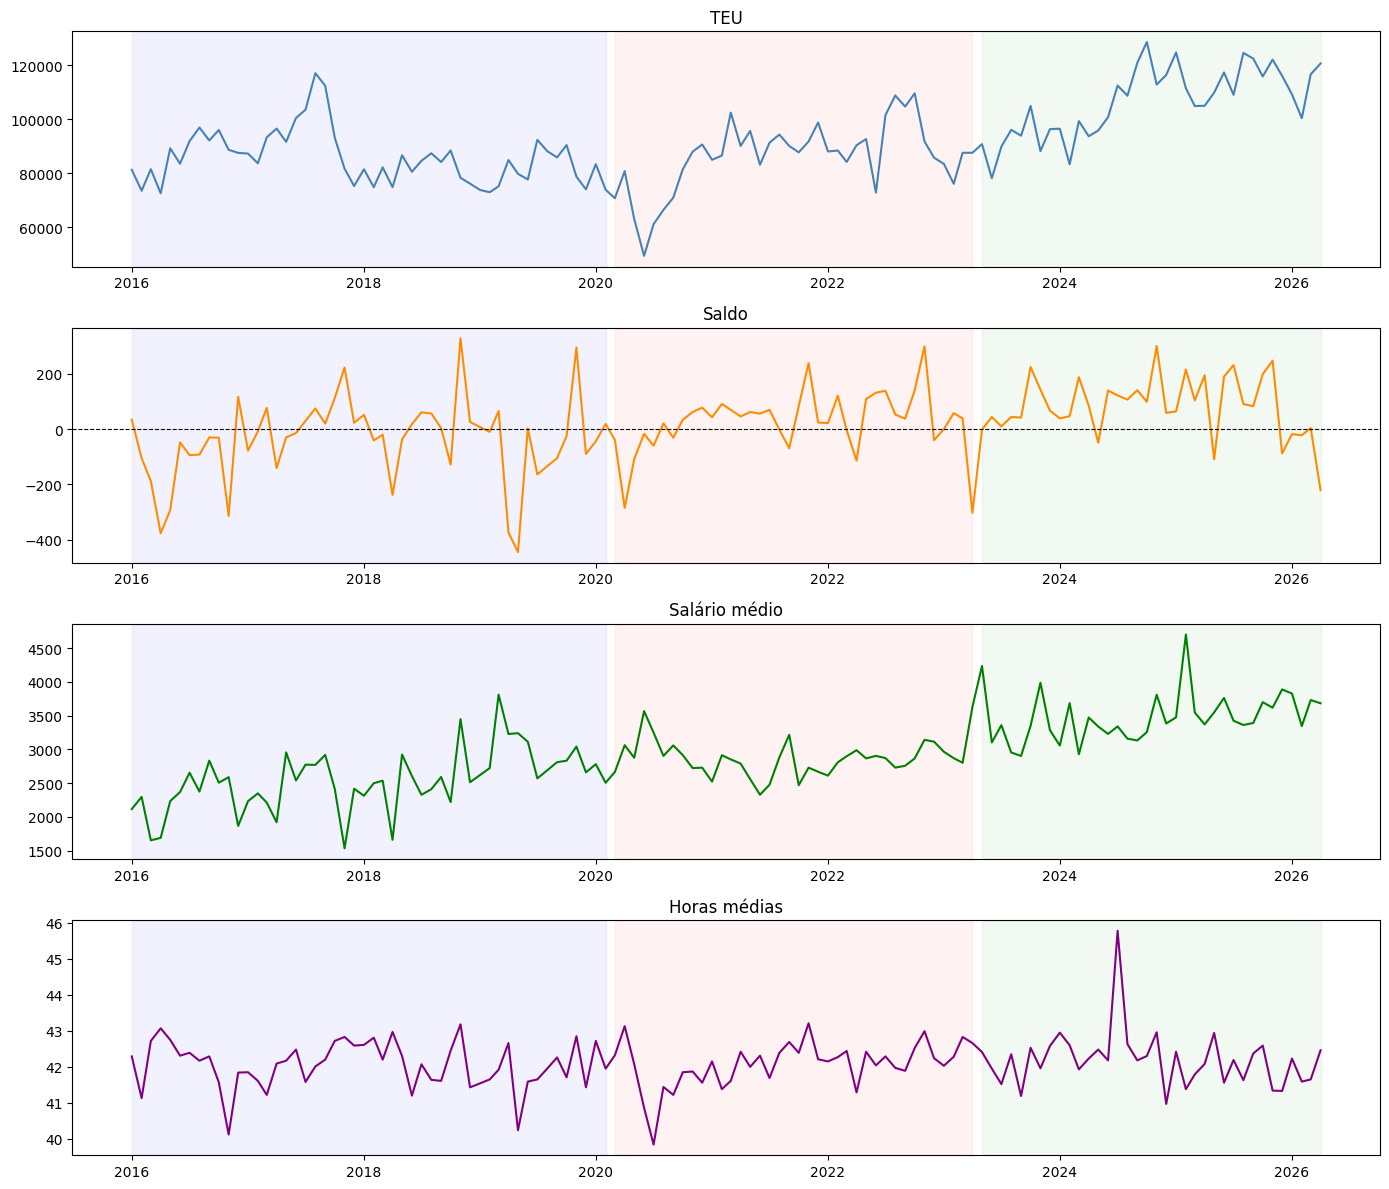

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

axes[0].plot(df['data'], df['teu'], color='steelblue')
axes[0].set_title('TEU')

axes[1].plot(df['data'], df['saldo'], color='darkorange')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Saldo')

axes[2].plot(df['data'], df['salario_media'], color='green')
axes[2].set_title('Salário médio')

axes[3].plot(df['data'], df['horas_media'], color='purple')
axes[3].set_title('Horas médias')

for ax in axes:
    for periodo, grupo in df.groupby('covid'):
        cor = {0: 'blue', 1: 'red', 2: 'green'}[periodo]
        ax.axvspan(grupo['data'].min(), grupo['data'].max(), alpha=0.05, color=cor)

plt.tight_layout()
plt.show()

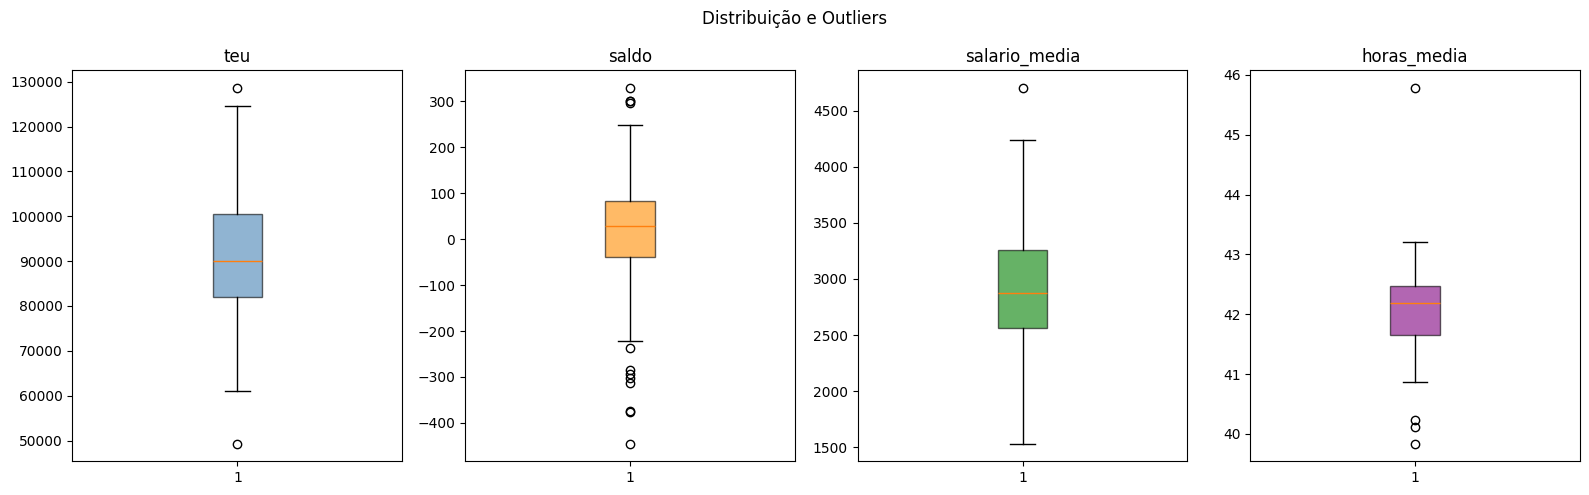

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col, cor in zip(axes,
                        ['teu', 'saldo', 'salario_media', 'horas_media'],
                        ['steelblue', 'darkorange', 'green', 'purple']):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=cor, alpha=0.6))
    ax.set_title(col)

plt.suptitle('Distribuição e Outliers')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2574/1386771977.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mês', y='saldo', palette='coolwarm')


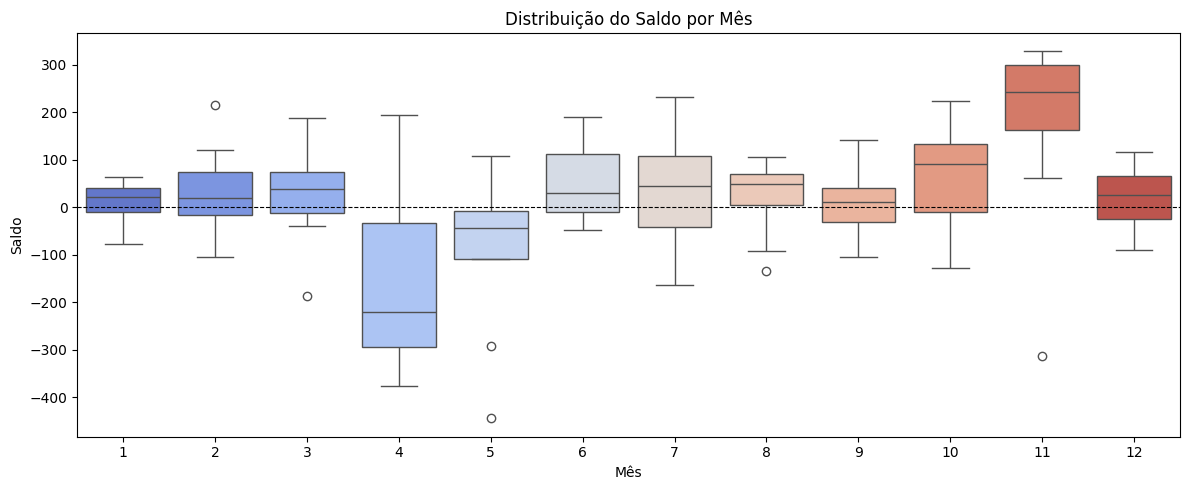

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='mês', y='saldo', palette='coolwarm')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Distribuição do Saldo por Mês')
plt.xlabel('Mês')
plt.ylabel('Saldo')
plt.tight_layout()
plt.show()

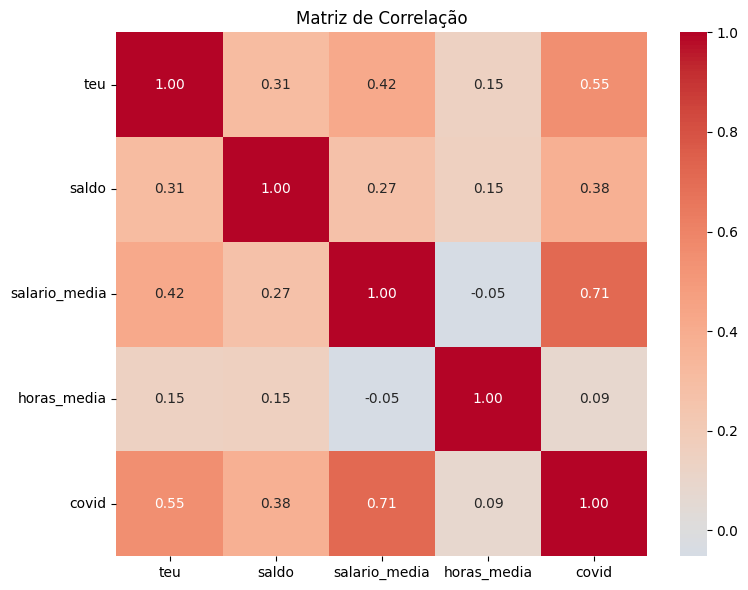

In [ ]:
correlacoes = df[['teu', 'saldo', 'salario_media', 'horas_media', 'covid']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacoes, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()


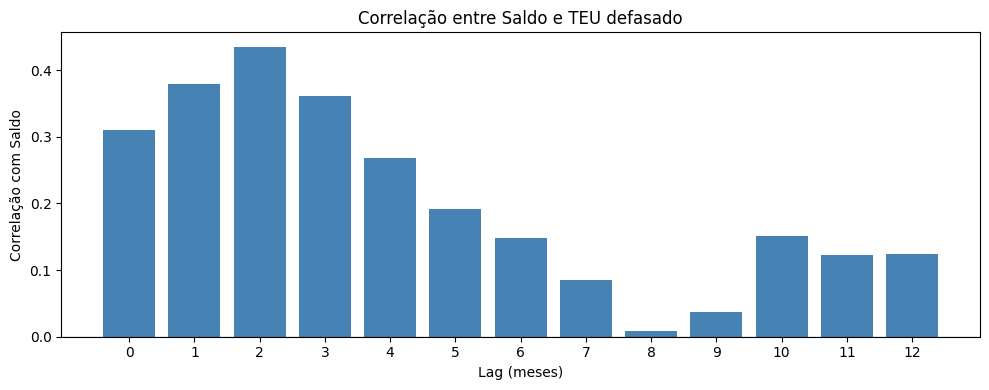

In [ ]:
lags = range(0, 13)
correlacoes_lag = [df['saldo'].corr(df['teu'].shift(lag)) for lag in lags]

plt.figure(figsize=(10, 4))
plt.bar(lags, correlacoes_lag, color='steelblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Lag (meses)')
plt.ylabel('Correlação com Saldo')
plt.title('Correlação entre Saldo e TEU defasado')
plt.xticks(list(lags))
plt.tight_layout()
plt.show()

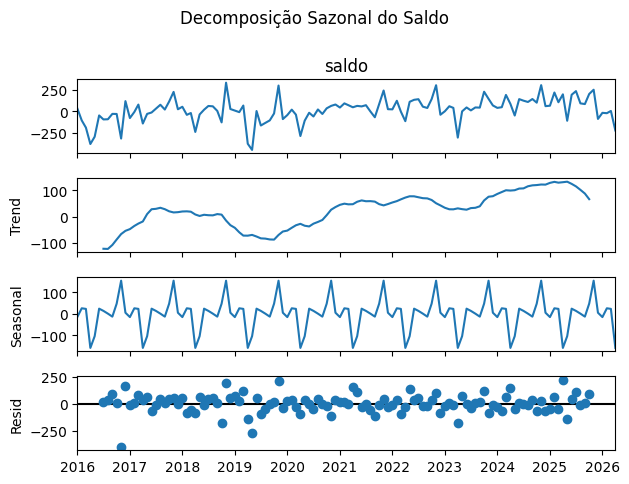

In [ ]:
decomposicao = seasonal_decompose(
    df.set_index('data')['saldo'],
    model='additive',
    period=12
)

decomposicao.plot()
plt.suptitle('Decomposição Sazonal do Saldo', y=1)
plt.tight_layout()
plt.show()


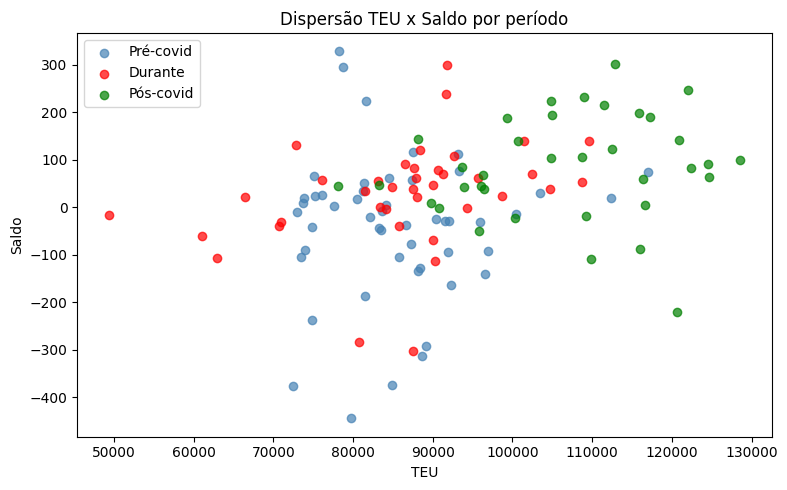

In [ ]:
cores  = {0: 'steelblue', 1: 'red',      2: 'green'}
labels = {0: 'Pré-covid', 1: 'Durante',  2: 'Pós-covid'}

plt.figure(figsize=(8, 5))
for periodo, grupo in df.groupby('covid'):
    plt.scatter(grupo['teu'], grupo['saldo'],
                color=cores[periodo], label=labels[periodo], alpha=0.7)

plt.xlabel('TEU')
plt.ylabel('Saldo')
plt.title('Dispersão TEU x Saldo por período')
plt.legend()
plt.tight_layout()
plt.show()


Correlação salário x horas: -0.0516
Correlação aceitável


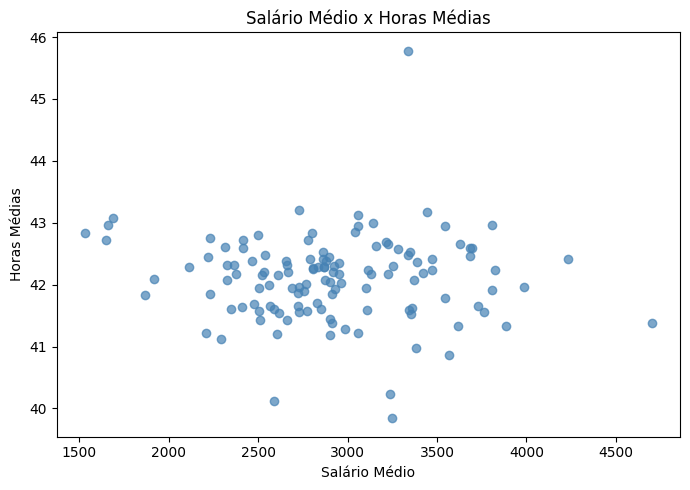

In [ ]:
corr_sal_horas = df['salario_media'].corr(df['horas_media'])
print(f"\nCorrelação salário x horas: {corr_sal_horas:.4f}")
print("Atenção para multicolinearidade" if abs(corr_sal_horas) > 0.8 else "Correlação aceitável")

plt.figure(figsize=(7, 5))
plt.scatter(df['salario_media'], df['horas_media'], alpha=0.7, color='steelblue')
plt.xlabel('Salário Médio')
plt.ylabel('Horas Médias')
plt.title('Salário Médio x Horas Médias')
plt.tight_layout()
plt.show()



In [ ]:
def teste_adf(serie, nome):
    resultado = adfuller(serie.dropna())
    print(f'\n{nome}')
    print(f'  Estatística ADF : {resultado[0]:.4f}')
    print(f'  p-valor         : {resultado[1]:.4f}')
    print(f'  Estacionária    : {"Sim" if resultado[1] < 0.05 else "Não"}')

teste_adf(df['saldo'],'Saldo')
teste_adf(df['teu'],'TEU')
teste_adf(df['salario_media'],'Salário Média')
teste_adf(df['horas_media'],  'Horas Médias')


Saldo
  Estatística ADF : -2.1079
  p-valor         : 0.2414
  Estacionária    : Não

TEU
  Estatística ADF : -2.4350
  p-valor         : 0.1321
  Estacionária    : Não

Salário Média
  Estatística ADF : -1.6370
  p-valor         : 0.4638
  Estacionária    : Não

Horas Médias
  Estatística ADF : -9.1160
  p-valor         : 0.0000
  Estacionária    : Sim


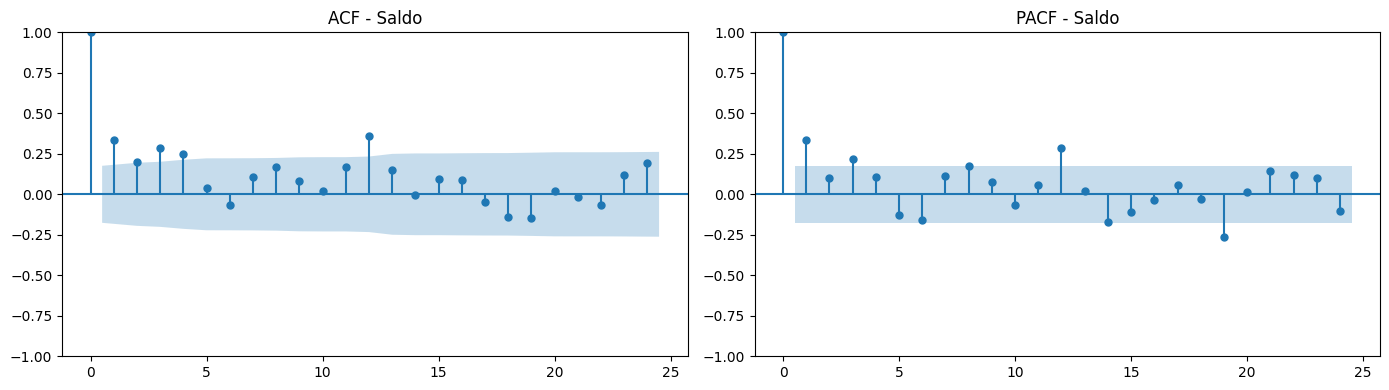

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df['saldo'].dropna(),  lags=24, ax=axes[0])
plot_pacf(df['saldo'].dropna(), lags=24, ax=axes[1])
axes[0].set_title('ACF - Saldo')
axes[1].set_title('PACF - Saldo')

plt.tight_layout()
plt.show()

A análise exploratória dos dados, abrangendo o período de janeiro de 2016 a abril de 2026, totalizando 124 observações mensais, revela padrões relevantes para a especificação dos modelos subsequentes.

 A série de TEU apresenta tendência crescente moderada com alta volatilidade, evidenciando três regimes distintos: oscilação lateral entre 70 e 100 mil unidades no período pré-pandemia, queda abrupta em meados de 2020 chegando a aproximadamente 49 mil unidades, e crescimento acentuado a partir de 2023, atingindo picos próximos a 130 mil unidades.

 A série de saldo de empregos apresenta volatilidade ainda maior, com picos e vales acentuados que se corrigem com frequência, exceto durante um período de relativa estabilização entre meados de 2020 e meados de 2021.

  A distribuição apresenta leve assimetria negativa, com outliers relevantes na cauda esquerda, notadamente em maio de 2019, novembro de 2016 e durante o período pandêmico.A matriz de correlação de Pearson indica correlação contemporânea fraca a moderada entre TEU e saldo, de 0,31.
  
  Observa-se correlação moderada a forte entre covid e salário médio, de 0,71, e entre covid e TEU, de 0,55, sugerindo que a variável covid pode estar capturando, em parte, efeitos de outras variáveis macroeconômicas não incluídas explicitamente no modelo. A correlação entre salário médio e horas médias é praticamente nula, de menos 0,05, descartando preocupações de multicolinearidade entre essas variáveis.A análise de correlação entre saldo e TEU defasado indica que a defasagem de dois meses apresenta a maior correlação, de aproximadamente 0,43, seguida pela defasagem de um e três meses, justificando a inclusão dessas defasagens nos modelos com componente temporal.
  
  O teste de Dickey-Fuller Aumentado rejeitou a hipótese de estacionariedade da série de saldo em nível, com estatística de -2,1079 e p-valor de 0,2414.  
   
   Os gráficos de função de autocorrelação e autocorrelação parcial indicam dependência temporal de curto prazo, com coeficientes significativos nas primeiras defasagens, sem evidenciar o padrão de decaimento lento característico de séries fortemente não estacionárias.
   
   A decomposição sazonal aditiva revela componente sazonal regular e bem definido, com picos recorrentes em determinados meses do ano, e componente de tendência que acompanha de perto o comportamento de longo prazo do TEU.

## Feature Engineering

In [ ]:
#Dummies de Covid-19 para modelos econométricos
df['covid_durante'] = (df['covid'] == 1).astype(int)
df['covid_pos']     = (df['covid'] == 2).astype(int)

In [ ]:
#Diferenciação
df['saldo_diff'] = df['saldo'].diff()
teste_adf(df['saldo_diff'].dropna(), 'Saldo Diferenciado')


Saldo Diferenciado
  Estatística ADF : -6.6136
  p-valor         : 0.0000
  Estacionária    : Sim


A diferenciação é uma técnica utilizada para tornar uma série temporal estacionária, calculando a variação entre períodos consecutivos. Ela é necessária porque modelos econométricos a serem abordados assumem que a série possui propriedades estatísticas estáveis ao longo do tempo. Quando a primeira diferenciação não é suficiente para alcançar a estacionariedade, pode-se aplicar uma segunda diferenciação.

Após a primeira diferenciação, a série rejeitou a hipótese de raiz unitária ao nível de 5%, sendo classificada como integrada de ordem 1. Esse resultado orientou a especificação da ordem de integração do modelo SARIMAX, com parâmetro d=1.

In [ ]:
#EDA indicou melhora na correlação nas 3 primeiras defasagens de Teus, defasagem 12 captura sazonalidade
df['teu_lag1']  = df['teu'].shift(1)
df['teu_lag2']  = df['teu'].shift(2)
df['teu_lag3']  = df['teu'].shift(3)
df['teu_lag12'] = df['teu'].shift(12)
#Para autocorrelação identificada no ACF
df['saldo_lag1']  = df['saldo'].shift(1)
df['saldo_lag12'] = df['saldo'].shift(12)
#Média móveis
df['teu_mm3']  = df['teu'].rolling(3).mean()
df['teu_mm6']  = df['teu'].rolling(6).mean()
df['teu_mm12'] = df['teu'].rolling(12).mean()
#variação percentual de TEU
df['teu_var_pct'] = df['teu'].pct_change()


In [ ]:
df['trimestre'] = df['data'].dt.quarter

dummies_mes = pd.get_dummies(df['mês'], prefix='mês', drop_first=True).astype(int) #Dummies mensais para sazonalidade
df = pd.concat([df, dummies_mes], axis=1)
dummies_cols = [col for col in df.columns if col.startswith('mês_')]

df['salario_hora_media'] = df['salario_media'] / df['horas_media'] #Alternativa a salário e horas separados se houver multicolinearidade

In [ ]:
df.head()

,ano,mês,covid,salario_media,horas_media,teu,saldo,data,covid_durante,covid_pos,...,mês_4,mês_5,mês_6,mês_7,mês_8,mês_9,mês_10,mês_11,mês_12,salario_hora_media
0,2016,1,0,2116.05,42.29,81220,34,2016-01-01,0,0,...,0,0,0,0,0,0,0,0,0,50.036652
1,2016,2,0,2295.56,41.13,73466,-105,2016-02-01,0,0,...,0,0,0,0,0,0,0,0,0,55.812302
2,2016,3,0,1652.68,42.72,81463,-188,2016-03-01,0,0,...,0,0,0,0,0,0,0,0,0,38.686330
3,2016,4,0,1689.02,43.07,72511,-377,2016-04-01,0,0,...,1,0,0,0,0,0,0,0,0,39.215695
4,2016,5,0,2233.69,42.75,89188,-293,2016-05-01,0,0,...,0,1,0,0,0,0,0,0,0,52.250058


In [ ]:
# features por modelo
features_economicos = [
    'teu', 'salario_media', 'horas_media', 'mês',
    'covid_durante', 'covid_pos', 'saldo','data',
] + dummies_cols

features_defasagem = [
    'teu', 'teu_lag1', 'teu_lag2', 'teu_lag3',
    'salario_media', 'horas_media',
    'covid_durante', 'covid_pos', 'saldo'
]

features_ml = [
    'teu', 'teu_lag1', 'teu_lag2', 'teu_lag3',
    'teu_mm3', 'teu_mm6', 'teu_mm12',
    'teu_var_pct', 'salario_media', 'horas_media',
    'covid', 'mês', 'ano', 'trimestre'
]

#Subconjuntos com dropna local
df_economicos  = df[features_economicos].dropna().reset_index(drop=True)
df_defasagem   = df[features_defasagem].dropna().reset_index(drop=True)
df_ml = df[features_ml + ['saldo']].dropna().reset_index(drop=True)

print(f"Observações econométricos : {len(df_economicos)}")
print(f"Observações defasagem     : {len(df_defasagem)}")
print(f"Observações ML            : {len(df_ml)}")

Observações econométricos : 124
Observações defasagem     : 121
Observações ML            : 113


A aplicação de defasagens temporais e médias móveis implica necessariamente na perda das primeiras observações da série. No caso do modelo com defasagem, a perda é de 3 observações referentes  de TEU, enquanto nos modelos de aprendizado de máquina a perda chega a 11 observações devido à inclusão da média móvel de 12 meses. Os modelos econométricos mais simples, por não dependerem de defasagens ou médias móveis, utilizam a série completa.

## Modelagem Econométrica sem ajuste

As próximas modelagens, gráficos e análise correspondem apenas aos modelos econométricos dentro da amostra, não implementando ajuste dos dados para predição.

In [ ]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [ ]:
#Variável dependente
y = df_economicos['saldo']


In [ ]:
#Regressão linear Simples
X1 = sm.add_constant(df_economicos['teu'])
modelo_rl1 = sm.OLS(y, X1).fit()
print(modelo_rl1.summary())

                            OLS Regression Results                            
Dep. Variable:                  saldo   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     12.92
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           0.000471
Time:                        03:45:44   Log-Likelihood:                -780.23
No. Observations:                 124   AIC:                             1564.
Df Residuals:                     122   BIC:                             1570.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -245.1978     73.740     -3.325      0.0

In [ ]:
#Sazonalidade simples
X3 = sm.add_constant(df_economicos[['teu', 'covid_durante', 'covid_pos'] + dummies_cols])
modelo_saz1 = sm.OLS(y, X3).fit()
print(modelo_saz1.summary())

                            OLS Regression Results                            
Dep. Variable:                  saldo   R-squared:                       0.490
Model:                            OLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     7.475
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           9.63e-11
Time:                        03:45:44   Log-Likelihood:                -744.74
No. Observations:                 124   AIC:                             1519.
Df Residuals:                     109   BIC:                             1562.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -182.4165     82.007     -2.224

In [ ]:
#sazonalidade Robusta - utilizando séries de Fourier
for k in range(1, 3):
    df_economicos[f'sen_{k}'] = np.sin(2 * np.pi * k * df_economicos['mês'] / 12)
    df_economicos[f'cos_{k}'] = np.cos(2 * np.pi * k * df_economicos['mês'] / 12)

fourier_cols = [col for col in df_economicos.columns if col.startswith('sen_') or col.startswith('cos_')]

X4 = sm.add_constant(df_economicos[['teu', 'covid_durante', 'covid_pos'] + fourier_cols])
modelo_saz2 = sm.OLS(y, X4).fit()
print(modelo_saz2.summary())

                            OLS Regression Results                            
Dep. Variable:                  saldo   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     7.391
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           2.47e-07
Time:                        03:45:44   Log-Likelihood:                -763.60
No. Observations:                 124   AIC:                             1543.
Df Residuals:                     116   BIC:                             1566.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -122.2476     85.268     -1.434

In [ ]:
#Modelo com defasagem
y_def = df_defasagem['saldo']
X5    = sm.add_constant(df_defasagem[['teu', 'teu_lag1', 'teu_lag2', 'teu_lag3',
                                       'covid_durante', 'covid_pos',
                                       'salario_media', 'horas_media']])
modelo_def = sm.OLS(y_def, X5).fit()
print(modelo_def.summary())

                            OLS Regression Results                            
Dep. Variable:                  saldo   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     4.653
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           6.23e-05
Time:                        03:45:44   Log-Likelihood:                -750.06
No. Observations:                 121   AIC:                             1518.
Df Residuals:                     112   BIC:                             1543.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1274.3392    723.840     -1.761

In [ ]:
#Sarimax
df_sarimax = df_economicos.copy()
df_sarimax = df_sarimax.set_index('data')
exog_cols = ['teu', 'salario_media', 'horas_media', 'covid_durante', 'covid_pos']
exog = df_sarimax[exog_cols]

modelo_sarimax = sm.tsa.SARIMAX(
    df_sarimax['saldo'],
    exog=exog,
    order=(1, 1, 1),           # p=2 (PACF), d=2 (I(2)), q=1,
    seasonal_order=(1, 0, 1, 12)
).fit(disp=False)
print(modelo_sarimax.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              saldo   No. Observations:                  124
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -761.672
Date:                            Tue, 16 Jun 2026   AIC                           1543.345
Time:                                    03:45:46   BIC                           1571.466
Sample:                                01-01-2016   HQIC                          1554.768
                                     - 04-01-2026                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
teu              -0.0002      0.002     -0.093      0.926      -0.004       0.004
salario_media     0.0081  

## Métricas

RMSE (Root Mean Squared Error) é a raiz do erro quadrático médio. Mede a magnitude média dos erros de previsão, elevando cada erro ao quadrado antes de calcular sua média e, posteriormente, extraindo a raiz quadrada.

\begin{equation}
RMSE = \sqrt{\frac{1}{n}\sum_{t=1}^{n}(y_t-\hat{y}_t)^2}
\end{equation}

Como os erros são elevados ao quadrado, erros maiores recebem penalização desproporcionalmente maior. Dessa forma, o RMSE é particularmente útil quando se deseja identificar modelos que evitam grandes desvios de previsão.

MAE (Mean Absolute Error) é o erro absoluto médio. Calcula a média das diferenças absolutas entre os valores observados e previstos.

\begin{equation}
MAE = \frac{1}{n}\sum_{t=1}^{n}|y_t-\hat{y}_t|
\end{equation}

Diferentemente do RMSE, o MAE atribui o mesmo peso a todos os erros, tornando-se menos sensível a valores extremos (outliers). Sua interpretação é direta, pois permanece na mesma unidade da variável analisada.

MASE (Mean Absolute Scaled Error) é o erro absoluto médio escalonado pelo erro de um modelo ingênuo (naive forecast), que prevê o próximo valor repetindo o último valor observado.

\begin{equation}
MASE =
\frac{
\frac{1}{n}\sum_{t=1}^{n}|y_t-\hat{y}_t|
}{
\frac{1}{n-1}\sum_{t=2}^{n}|y_t-y_{t-1}|
}
\end{equation}

Valores inferiores a 1 indicam que o modelo apresenta desempenho superior ao modelo ingênuo, enquanto valores superiores a 1 indicam desempenho inferior. O MASE é amplamente utilizado em séries temporais por permitir comparações entre séries de diferentes magnitudes.

R² (Coeficiente de Determinação) representa a proporção da variância da variável dependente explicada pelo modelo.

\begin{equation}
R^2 =
1 -
\frac{
\sum_{t=1}^{n}(y_t-\hat{y}_t)^2
}{
\sum_{t=1}^{n}(y_t-\bar{y})^2
}
\end{equation}

Valores próximos de 1 indicam melhor capacidade explicativa, enquanto valores próximos de 0 sugerem baixo poder de ajuste. Embora seja útil para avaliar o ajuste geral do modelo, em séries temporais o R² pode ser artificialmente elevado devido à presença de autocorrelação e tendências, não refletindo necessariamente boa capacidade preditiva fora da amostra.

In [ ]:
def metricas(y_real, y_pred, nome, y_treino=None):
    y_real = np.array(y_real)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    mask = y_real != 0
    r2   = 1 - np.sum((y_real - y_pred) ** 2) / np.sum((y_real - y_real.mean()) ** 2)

    if y_treino is not None:
        d    = np.mean(np.abs(np.diff(np.array(y_treino))))
        mase = mae / d if d != 0 else np.nan
    else:
        mase = np.nan

    print(f"\n{nome}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  MAE  : {mae:.2f}")
    print(f"  MASE : {mase:.4f}")
    print(f"  R²   : {r2:.4f}")

    return {'modelo': nome, 'RMSE': rmse, 'MAE': mae, 'MASE': mase, 'R2': r2}

 Os primeiros valores serão instáveis por definição enquanto o filtro ainda não convergiu por causa do burn-in period do filtro de Kalman que o SARIMAX utiliza. A solução pensada será ignorar os primeiros pontos na avaliação das métricas.

In [ ]:
resultados = []
resultados.append(metricas(y.values,     modelo_rl1.fittedvalues.values,     'RL Simples',           y.values))
resultados.append(metricas(y.values,     modelo_saz1.fittedvalues.values,    'Sazonalidade Simples', y.values))
resultados.append(metricas(y.values,     modelo_saz2.fittedvalues.values,    'Sazonalidade Robusta', y.values))
resultados.append(metricas(y_def.values, modelo_def.fittedvalues.values,     'Defasagem',            y_def.values))

# SARIMAX com burn-in de 12 meses
burnin = 12
y_sarimax_real   = df_sarimax['saldo'].values[burnin:]
y_sarimax_fitted = modelo_sarimax.fittedvalues.values[burnin:]
resultados.append(metricas(y_sarimax_real, y_sarimax_fitted, 'SARIMAX', y_sarimax_real))


RL Simples
  RMSE : 130.74
  MAE  : 94.01
  MASE : 0.8297
  R²   : 0.0957

Sazonalidade Simples
  RMSE : 98.20
  MAE  : 71.54
  MASE : 0.6313
  R²   : 0.4898

Sazonalidade Robusta
  RMSE : 114.33
  MAE  : 89.14
  MASE : 0.7867
  R²   : 0.3084

Defasagem
  RMSE : 119.09
  MAE  : 87.59
  MASE : 0.7771
  R²   : 0.2494

SARIMAX
  RMSE : 110.70
  MAE  : 87.44
  MASE : 0.7971
  R²   : 0.2627


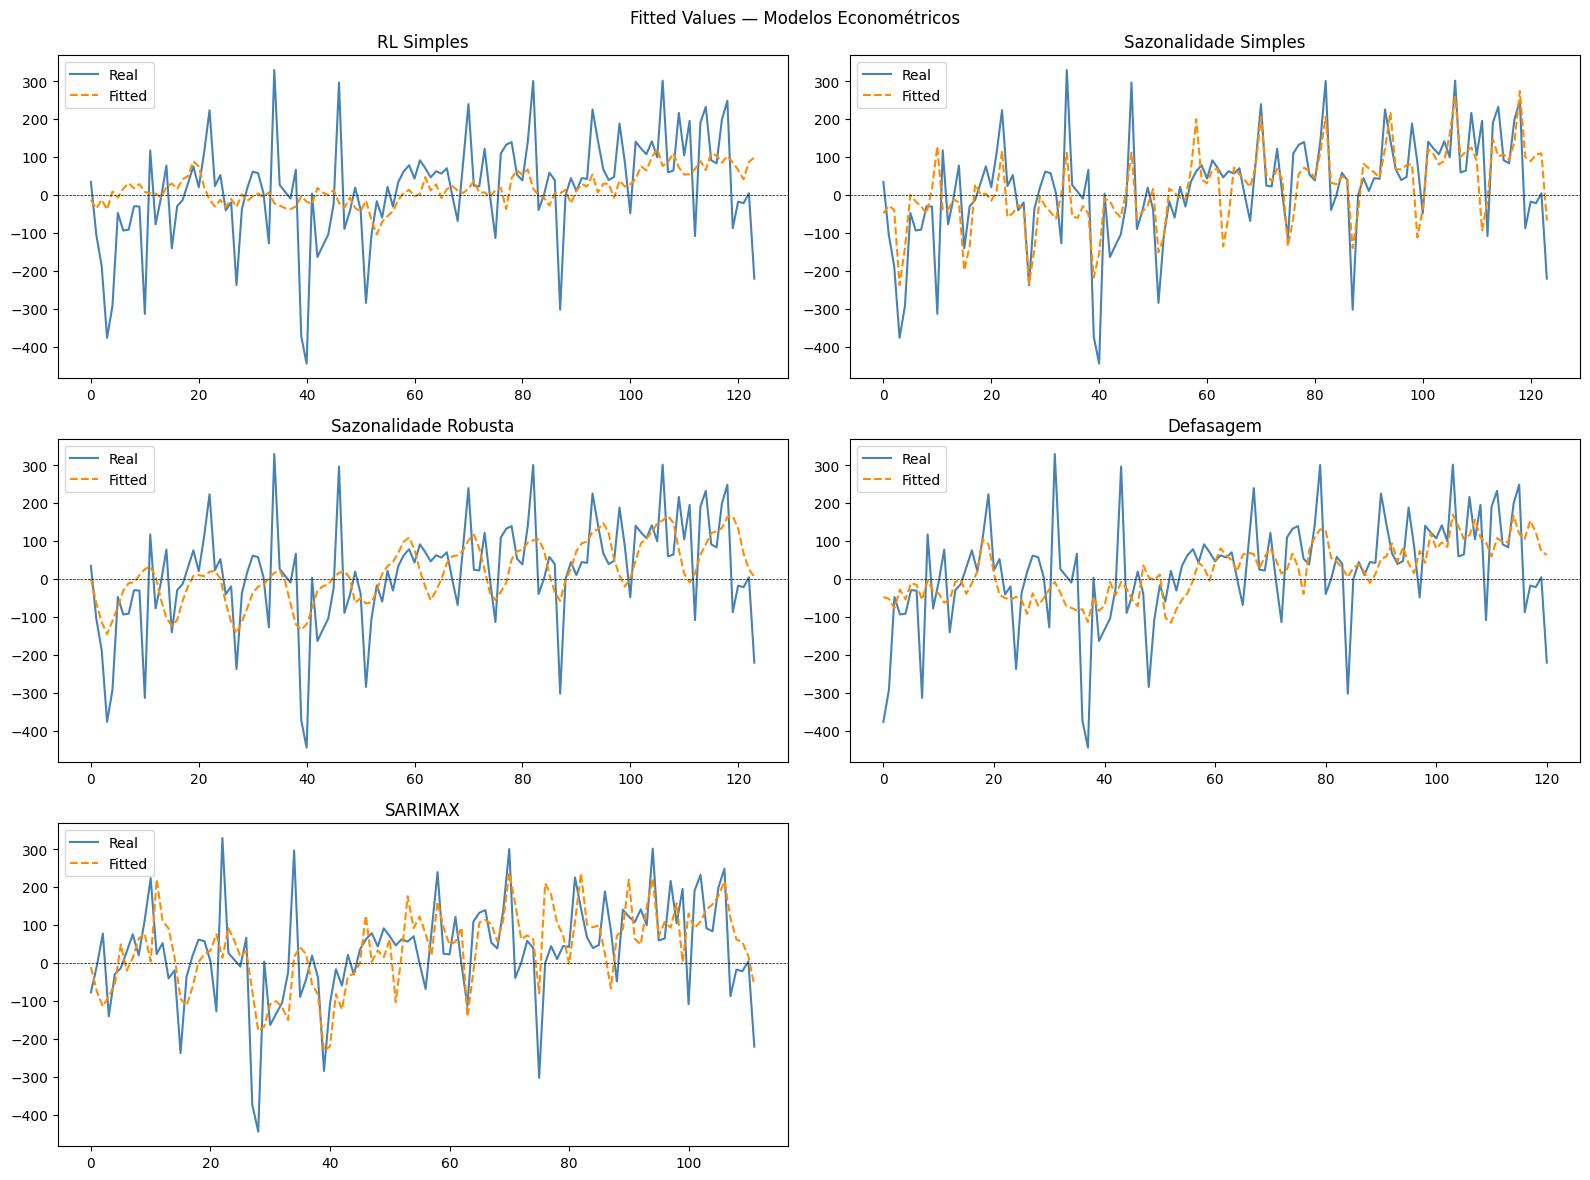

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

modelos_plot = [
    (y.values,           modelo_rl1.fittedvalues.values,    'RL Simples'),
    (y.values,           modelo_saz1.fittedvalues.values,   'Sazonalidade Simples'),
    (y.values,           modelo_saz2.fittedvalues.values,   'Sazonalidade Robusta'),
    (y_def.values,       modelo_def.fittedvalues.values,    'Defasagem'),
    (y_sarimax_real,     y_sarimax_fitted,                  'SARIMAX'),
]

for i, (y_real, y_fitted, nome) in enumerate(modelos_plot):
    axes[i].plot(y_real, label='Real', color='steelblue')
    axes[i].plot(y_fitted, label='Fitted', color='darkorange', linestyle='--')
    axes[i].set_title(nome)
    axes[i].legend()
    axes[i].axhline(0, color='black', linewidth=0.5, linestyle='--')

fig.delaxes(axes[5])

plt.suptitle('Fitted Values — Modelos Econométricos')
plt.tight_layout()
plt.show()

## Análise dos Modelos Econométricos para a amostra
A regressão linear simples, utilizando apenas a movimentação de TEUs como variável explicativa, apresentou o desempenho mais limitado entre os modelos econométricos avaliados, alcançando R² de 0,096 e MASE de 0,8297. A análise visual dos valores ajustados indica que o modelo reproduz apenas o nível médio da série e uma discreta tendência de crescimento ao longo do período, sem conseguir representar adequadamente a elevada volatilidade observada no saldo de empregos. Em particular, os principais picos e vales da série, especialmente aqueles próximos às observações 5, 40 e 90, não são capturados pelo modelo.

Entre os modelos econométricos, a Sazonalidade Simples apresentou o melhor desempenho, com R² de 0,490 e o menor valor de MASE (0,6313). Os valores ajustados demonstram maior aderência à série observada, reproduzindo de forma satisfatória a amplitude das oscilações e diversos movimentos de expansão e retração do emprego ao longo do período analisado. Embora os eventos extremos não sejam totalmente capturados, o modelo consegue representar de maneira consistente a dinâmica sazonal da série.

O modelo de Sazonalidade Robusta, baseado em componentes de Fourier, obteve desempenho intermediário, registrando R² de 0,308 e MASE de 0,7867. Comparativamente à Sazonalidade Simples, os valores ajustados apresentam comportamento mais suavizado, com transições graduais entre picos e vales. Tal característica decorre da natureza contínua das funções senoidais utilizadas na modelagem, em contraste com a maior flexibilidade proporcionada pelas variáveis indicadoras mensais.

O modelo de Defasagem apresentou R² de 0,249 e MASE de 0,7771. A inspeção gráfica revela um comportamento característico de resposta retardada, no qual os valores ajustados acompanham os movimentos da série observada com pequeno atraso temporal, particularmente entre as observações 30 e 50. Esse resultado é compatível com a hipótese de que a demanda por mão de obra responde à atividade portuária após determinado intervalo de tempo, refletindo o processo gradual de ajuste das decisões de contratação.

O modelo SARIMAX, especificado como (1,1,1)(1,0,1,12), alcançou R² de 0,263 e RMSE de 110,70, configurando o segundo menor erro absoluto entre os modelos econométricos analisados, atrás apenas da Sazonalidade Simples. Em comparação aos resultados obtidos com a base de dados anterior, observou-se melhora substancial tanto no coeficiente de determinação quanto no RMSE, sugerindo que a ampliação da amostra contribuiu para uma estimação mais estável dos componentes autorregressivos e sazonais, bem como para o processo de convergência do filtro de Kalman. O gráfico evidencia maior capacidade de acompanhar os movimentos da série, embora ainda sejam observadas discrepâncias nas primeiras observações, compatíveis com o período inicial de convergência do modelo.

De modo geral, a Sazonalidade Simples manteve-se como o modelo econométrico de melhor desempenho, apresentando simultaneamente o maior poder explicativo e o menor erro relativo em comparação ao modelo ingênuo.

## Modelos Machine Learning sem ajuste

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

In [ ]:
X_ml = df_ml[features_ml]
y_ml = df_ml['saldo']

In [ ]:
#Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)
rf.fit(X_ml, y_ml)
fitted_rf = rf.predict(X_ml)


In [ ]:
#XGBOOST
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
xgb.fit(X_ml, y_ml)
fitted_xgb = xgb.predict(X_ml)

In [ ]:
#LSTM
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_ml)
y_scaled = scaler_y.fit_transform(y_ml.values.reshape(-1, 1))

def criar_janelas(X, y, janela=6):
    Xs, ys = [], []
    for i in range(janela, len(X)):
        Xs.append(X[i-janela:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

janela = 6
X_lstm, y_lstm = criar_janelas(X_scaled, y_scaled, janela)

modelo_lstm = Sequential([
    LSTM(16, input_shape=(janela, X_lstm.shape[2])),
    Dropout(0.2),
    Dense(1)
])

modelo_lstm.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(patience=15, restore_best_weights=True)

modelo_lstm.fit(
    X_lstm, y_lstm,
    epochs=100,
    batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

fitted_lstm_scaled = modelo_lstm.predict(X_lstm)
fitted_lstm = scaler_y.inverse_transform(fitted_lstm_scaled).flatten()
y_lstm_real = scaler_y.inverse_transform(y_lstm).flatten()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


O gráfico estende-se apenas aos modelos de Machine Learning agindo dentro da amostra, não implementando ajuste dos dados para predição.

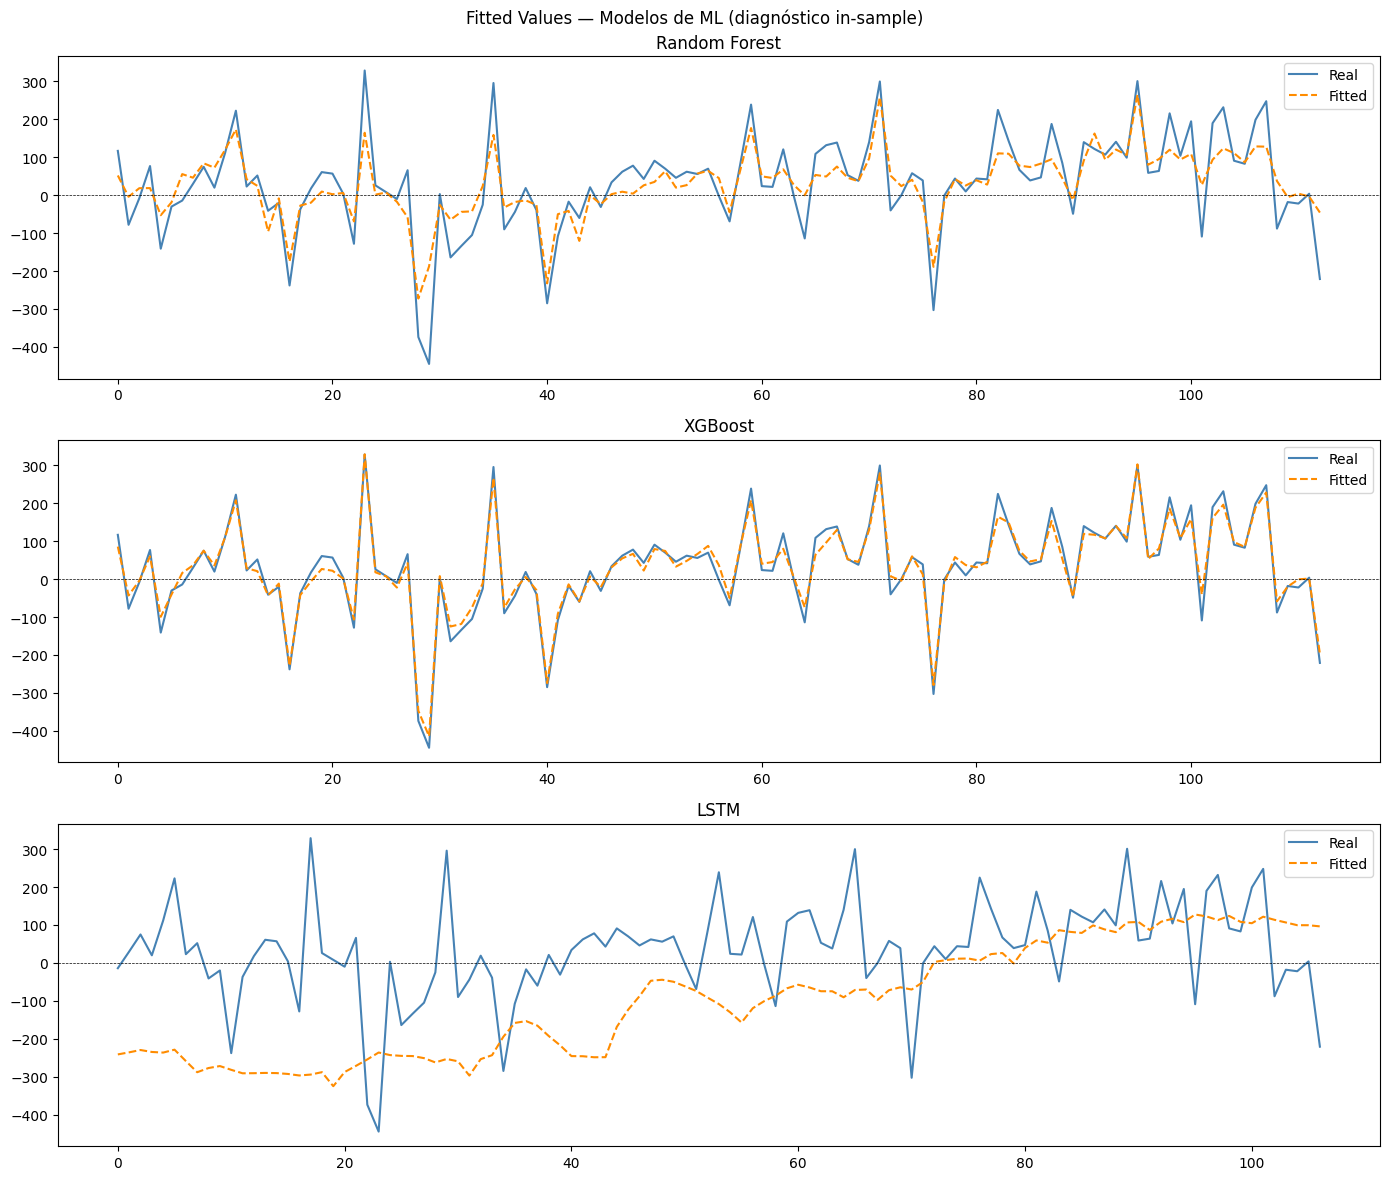

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

modelos_ml = [
    (y_ml.values, fitted_rf,   'Random Forest'),
    (y_ml.values, fitted_xgb,  'XGBoost'),
    (y_lstm_real, fitted_lstm, 'LSTM'),
]

for i, (y_real, y_fitted, nome) in enumerate(modelos_ml):
    axes[i].plot(y_real,   label='Real',   color='steelblue')
    axes[i].plot(y_fitted, label='Fitted', color='darkorange', linestyle='--')
    axes[i].set_title(nome)
    axes[i].legend()
    axes[i].axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.suptitle('Fitted Values — Modelos de ML (diagnóstico in-sample)')
plt.tight_layout()
plt.show()

## Modelagem Preditiva

Como ajuste dos modelos econométricos e de machine learning para averiguar a capacidade de predição e generalização com dados de teste será adotada a validação Walk-forward, que respeita a ordem cronológica dos dados ao garantir que os modelos sejam sempre treinados com observações passadas e avaliado em observações futuras

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.api as sm

n_splits = 10
tscv = TimeSeriesSplit(n_splits=n_splits)

resultados_wf = []

In [ ]:
def metricas_fold(y_real, y_pred, y_treino):
    y_real = np.array(y_real)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    mask = y_real != 0

    d = np.mean(np.abs(np.diff(np.array(y_treino))))
    mase = mae / d if d != 0 else np.nan

    if len(y_real) > 1:
        r2 = 1 - np.sum((y_real - y_pred) ** 2) / np.sum((y_real - y_real.mean()) ** 2)
    else:
        r2 = np.nan

    return {'RMSE': rmse, 'MAE': mae, 'MASE': mase, 'R2': r2}


def consolidar_resultados(nome_modelo, lista_metricas_por_fold):
    df_folds = pd.DataFrame(lista_metricas_por_fold)
    media = df_folds.mean(numeric_only=True)
    print(f"\n{nome_modelo} — média entre {len(lista_metricas_por_fold)} folds")
    print(df_folds.round(4))
    print("Médias:")
    print(media.round(4))
    return {'modelo': nome_modelo, **media.to_dict()}

In [ ]:
#Regressão Linear Simples
metricas_rl1 = []
X = sm.add_constant(df_economicos['teu'])
y = df_economicos['saldo']

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    modelo = sm.OLS(y_train, X_train).fit()
    pred = modelo.predict(X_test)

    metricas_rl1.append(metricas_fold(y_test.values, pred.values, y_train.values))

resultados_wf.append(consolidar_resultados('RL Simples', metricas_rl1))


RL Simples — média entre 10 folds
       RMSE       MAE    MASE      R2
0  154.4251  117.2982  0.8333 -2.1696
1  151.9722  114.2969  0.9673 -0.3189
2  202.8233  152.5648  1.2092 -0.0891
3   86.6871   59.6502  0.4488 -0.0527
4   95.9302   90.9801  0.6987 -3.9742
5  129.4773  110.6121  0.9682 -1.1595
6  137.4489   91.5458  0.8065 -0.0187
7  106.5570   90.2324  0.7791 -1.0194
8  112.1333   88.5577  0.7843 -0.2786
9  144.4502  120.0296  1.0652 -0.0465
Médias:
RMSE    132.1905
MAE     103.5768
MASE      0.8560
R2       -0.9127
dtype: float64


In [ ]:
#Sazonalidade simples
metricas_saz1 = []
dummies_cols = [col for col in df_economicos.columns if col.startswith('mês_')]
cols_saz1 = ['teu', 'covid_durante', 'covid_pos'] + dummies_cols

X = sm.add_constant(df_economicos[cols_saz1])
y = df_economicos['saldo']

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    modelo = sm.OLS(y_train, X_train).fit()
    pred = modelo.predict(X_test)

    metricas_saz1.append(metricas_fold(y_test.values, pred.values, y_train.values))

resultados_wf.append(consolidar_resultados('Sazonalidade Simples', metricas_saz1))


Sazonalidade Simples — média entre 10 folds
       RMSE       MAE    MASE      R2
0  217.3307  159.5710  1.1336 -5.2778
1  166.0073  131.3311  1.1114 -0.5738
2  145.5443  115.5211  0.9156  0.4392
3   80.0423   66.6845  0.5017  0.1025
4  113.5217   79.7631  0.6126 -5.9657
5   82.8082   70.2095  0.6145  0.1167
6   81.3961   65.5005  0.5771  0.6427
7   95.0351   64.9892  0.5611 -0.6063
8  110.3592   77.1763  0.6835 -0.2385
9  128.9895  108.7869  0.9654  0.1655
Médias:
RMSE    122.1034
MAE      93.9533
MASE      0.7676
R2       -1.1195
dtype: float64


In [ ]:
#Sazonalidade Robusta
metricas_saz2 = []
fourier_cols = [col for col in df_economicos.columns if col.startswith('sen_') or col.startswith('cos_')]
cols_saz2 = ['teu', 'covid_durante', 'covid_pos'] + fourier_cols

X = sm.add_constant(df_economicos[cols_saz2])
y = df_economicos['saldo']

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    modelo = sm.OLS(y_train, X_train).fit()
    pred = modelo.predict(X_test)

    metricas_saz2.append(metricas_fold(y_test.values, pred.values, y_train.values))

resultados_wf.append(consolidar_resultados('Sazonalidade Robusta', metricas_saz2))


Sazonalidade Robusta — média entre 10 folds
       RMSE       MAE    MASE      R2
0  179.1538  145.9404  1.0367 -3.2660
1  153.5041  122.3597  1.0355 -0.3457
2  170.1801  141.2395  1.1194  0.2333
3   93.3443   81.3929  0.6124 -0.2205
4  113.6860   91.7857  0.7049 -5.9859
5  103.2719   89.7463  0.7855 -0.3738
6  125.8329  106.2150  0.9358  0.1462
7   94.8881   77.1487  0.6661 -0.6013
8  110.8012   91.8124  0.8131 -0.2485
9  146.7380  122.5917  1.0879 -0.0800
Médias:
RMSE    129.1400
MAE     107.0232
MASE      0.8797
R2       -1.0742
dtype: float64


In [ ]:
#Defasagem
metricas_def = []
cols_def = ['teu', 'teu_lag1', 'teu_lag2', 'teu_lag3',
            'covid_durante', 'covid_pos', 'salario_media', 'horas_media']

X_full = sm.add_constant(df_defasagem[cols_def])
y_full = df_defasagem['saldo']

for train_idx, test_idx in tscv.split(X_full):
    X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]

    modelo = sm.OLS(y_train, X_train).fit()
    pred = modelo.predict(X_test)

    metricas_def.append(metricas_fold(y_test.values, pred.values, y_train.values))

resultados_wf.append(consolidar_resultados('Defasagem', metricas_def))


Defasagem — média entre 10 folds
       RMSE       MAE    MASE      R2
0  233.1808  193.8040  1.3658 -6.2268
1  192.7402  164.6176  1.4256 -1.1215
2  192.4971  137.5468  1.0990  0.0190
3  184.6451  147.2138  1.1100 -3.7759
4   93.5405   74.0125  0.5701 -3.7294
5   87.4874   71.6521  0.6330  0.0140
6  141.6519   88.4117  0.7853 -0.0820
7   93.1927   78.7834  0.6845 -0.5446
8  115.0948   79.9655  0.7129 -0.3471
9  158.2055  129.5646  1.1566 -0.2553
Médias:
RMSE    149.2236
MAE     116.5572
MASE      0.9543
R2       -1.6050
dtype: float64


In [ ]:
#SARIMAX

metricas_sarimax = []
exog_cols = ['teu', 'salario_media', 'horas_media', 'covid_durante', 'covid_pos']

df_sarimax_idx = df_economicos.set_index('data')

for train_idx, test_idx in tscv.split(df_sarimax_idx):
    train = df_sarimax_idx.iloc[train_idx]
    test  = df_sarimax_idx.iloc[test_idx]

    try:
        modelo = sm.tsa.SARIMAX(
            train['saldo'],
            exog=train[exog_cols],
            order=(1, 1, 1),
            seasonal_order=(1, 0, 1, 12)
        ).fit(disp=False)

        pred = modelo.forecast(steps=len(test), exog=test[exog_cols])

        metricas_sarimax.append(metricas_fold(test['saldo'].values, pred.values, train['saldo'].values))
    except Exception as e:
        print(f"Fold ignorado no SARIMAX: {e}")

resultados_wf.append(consolidar_resultados('SARIMAX', metricas_sarimax))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: C


SARIMAX — média entre 10 folds
       RMSE       MAE    MASE       R2
0  147.0575  116.5807  0.8282  -1.8743
1  146.0526  105.6032  0.8937  -0.2182
2  198.1357  143.3326  1.1360  -0.0393
3   98.2930   77.9247  0.5863  -0.3534
4  219.7844  191.3775  1.4698 -25.1097
5   73.9449   66.0238  0.5779   0.2957
6  193.9181  158.5723  1.3970  -1.0278
7   97.3383   84.2555  0.7275  -0.6851
8  120.8064   92.4684  0.8189  -0.4841
9  123.2288  105.2142  0.9337   0.2384
Médias:
RMSE    141.8560
MAE     114.1353
MASE      0.9369
R2       -2.9258
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
#Random Forest
metricas_rf = []
X_full = df_ml[features_ml]
y_full = df_ml['saldo']

for train_idx, test_idx in tscv.split(X_full):
    X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]

    modelo = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=2, random_state=42)
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    metricas_rf.append(metricas_fold(y_test.values, pred, y_train.values))

resultados_wf.append(consolidar_resultados('Random Forest', metricas_rf))


Random Forest — média entre 10 folds
       RMSE       MAE    MASE       R2
0   93.9436   63.1527  0.6102  -0.1158
1  211.8183  153.6098  1.6162  -0.0017
2   86.9028   74.1701  0.5762   0.5994
3  173.7501  158.7501  1.1872 -13.5838
4   70.4065   54.9127  0.4736   0.1687
5  101.8562   93.3425  0.8476   0.1382
6  101.5653   68.4922  0.6150   0.3149
7   85.4047   72.3594  0.6536  -0.7993
8  104.9976   78.3122  0.7298   0.0207
9  155.5816  135.4342  1.2166  -0.2001
Médias:
RMSE    118.6227
MAE      95.2536
MASE      0.8526
R2       -1.3459
dtype: float64


In [ ]:
#XGBOOST
metricas_xgb = []

for train_idx, test_idx in tscv.split(X_full):
    X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]

    modelo = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, verbosity=0)
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    metricas_xgb.append(metricas_fold(y_test.values, pred, y_train.values))

resultados_wf.append(consolidar_resultados('XGBoost', metricas_xgb))



XGBoost — média entre 10 folds
       RMSE       MAE    MASE       R2
0  110.1380   76.9674  0.7436  -0.5337
1  230.0248  163.1041  1.7161  -0.1813
2  140.7864  115.1064  0.8942  -0.0514
3  223.3368  193.3076  1.4457 -23.0958
4   79.4217   61.1288  0.5272  -0.0578
5  102.5828   87.8341  0.7976   0.1259
6   80.9467   55.1773  0.4954   0.5648
7  102.1761   92.0030  0.8310  -1.5753
8   98.1279   77.1627  0.7191   0.1447
9  157.6943  137.9389  1.2391  -0.2329
Médias:
RMSE    132.5235
MAE     105.9730
MASE      0.9409
R2       -2.4893
dtype: float64


In [ ]:
#LSTM

metricas_lstm = []
janela = 6

for train_idx, test_idx in tscv.split(X_lstm):
    X_train, X_test = X_lstm[train_idx], X_lstm[test_idx]
    y_train, y_test = y_lstm[train_idx], y_lstm[test_idx]

    if len(X_train) < 10:
        continue

    modelo = Sequential([
        LSTM(16, input_shape=(janela, X_lstm.shape[2])),
        Dropout(0.2),
        Dense(1)
    ])
    modelo.compile(optimizer='adam', loss='mse')

    modelo.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0,
               callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
               validation_split=0.1)

    pred_scaled = modelo.predict(X_test, verbose=0)
    pred = scaler_y.inverse_transform(pred_scaled).flatten()
    y_test_real = scaler_y.inverse_transform(y_test).flatten()
    y_train_real = scaler_y.inverse_transform(y_train).flatten()

    metricas_lstm.append(metricas_fold(y_test_real, pred, y_train_real))

resultados_wf.append(consolidar_resultados('LSTM', metricas_lstm))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l


LSTM — média entre 10 folds
       RMSE       MAE    MASE       R2
0  207.6771  177.5042  2.0344   0.1243
1  212.4815  174.2440  1.2835  -1.1168
2  258.5970  225.6869  1.6491 -19.1732
3   63.0142   38.9030  0.3192  -0.7496
4  107.4975  101.9426  0.9364  -0.2253
5  152.4649  105.4305  0.9713  -0.0300
6   64.1602   51.1889  0.4604   0.0979
7   70.5787   61.9286  0.5709  -0.2199
8  116.7496  106.4089  1.0120  -0.0112
9  183.2466  150.5480  1.3645  -0.8292
Médias:
RMSE    143.6467
MAE     119.3786
MASE      1.0602
R2       -2.2133
dtype: float64


In [ ]:
modelos_metricas = {
    'RL Simples'          : metricas_rl1,
    'Sazonalidade Simples': metricas_saz1,
    'Sazonalidade Robusta': metricas_saz2,
    'Defasagem'           : metricas_def,
    'SARIMAX'             : metricas_sarimax,
    'Random Forest'       : metricas_rf,
    'XGBoost'             : metricas_xgb,
    'LSTM'                : metricas_lstm,
}

folds_excluir = [3, 4]

resultados_completo = []
resultados_sem_covid = []

for nome, lista_folds in modelos_metricas.items():
    df_folds = pd.DataFrame(lista_folds)

    media_completa = df_folds.mean(numeric_only=True)
    resultados_completo.append({'modelo': nome, **media_completa.to_dict()})

    df_sem = df_folds.drop(index=[i for i in folds_excluir if i in df_folds.index])
    media_sem = df_sem.mean(numeric_only=True)
    resultados_sem_covid.append({'modelo': nome, **media_sem.to_dict()})

tabela_completa  = pd.DataFrame(resultados_completo)
tabela_sem_covid = pd.DataFrame(resultados_sem_covid)

print(tabela_completa[['modelo', 'RMSE', 'MAE', 'R2']].round(4).to_string(index=False))


              modelo     RMSE      MAE      R2
          RL Simples 132.1905 103.5768 -0.9127
Sazonalidade Simples 122.1034  93.9533 -1.1195
Sazonalidade Robusta 129.1400 107.0232 -1.0742
           Defasagem 149.2236 116.5572 -1.6050
             SARIMAX 141.8560 114.1353 -2.9258
       Random Forest 118.6227  95.2536 -1.3459
             XGBoost 132.5235 105.9730 -2.4893
                LSTM 143.6467 119.3786 -2.2133


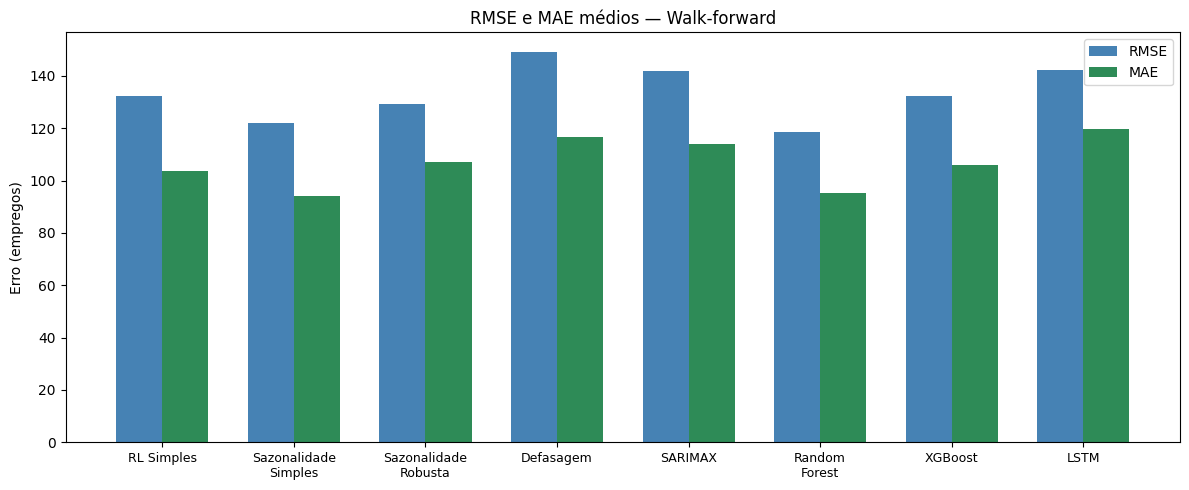

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

modelos = ['RL Simples', 'Sazonalidade\nSimples', 'Sazonalidade\nRobusta',
           'Defasagem', 'SARIMAX', 'Random\nForest', 'XGBoost', 'LSTM']

rmse = [132.19, 122.10, 129.14, 149.22, 141.86, 118.62, 132.52, 142.17]
mae  = [103.58, 93.95, 107.02, 116.56, 114.14, 95.25, 105.97, 119.84]
mase = [0.856, 0.768, 0.880, 0.954, 0.937, 0.853, 0.941, 1.091]
r2   = [-0.913, -1.120, -1.074, -1.605, -2.926, -1.346, -2.489, -1.194]

x = np.arange(len(modelos))

fig, ax = plt.subplots(figsize=(12, 5))
largura = 0.35

ax.bar(x - largura/2, rmse, largura, label='RMSE', color='steelblue')
ax.bar(x + largura/2, mae, largura, label='MAE', color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=9)
ax.set_ylabel('Erro (empregos)')
ax.set_title('RMSE e MAE médios — Walk-forward')
ax.legend()

plt.tight_layout()
plt.show()



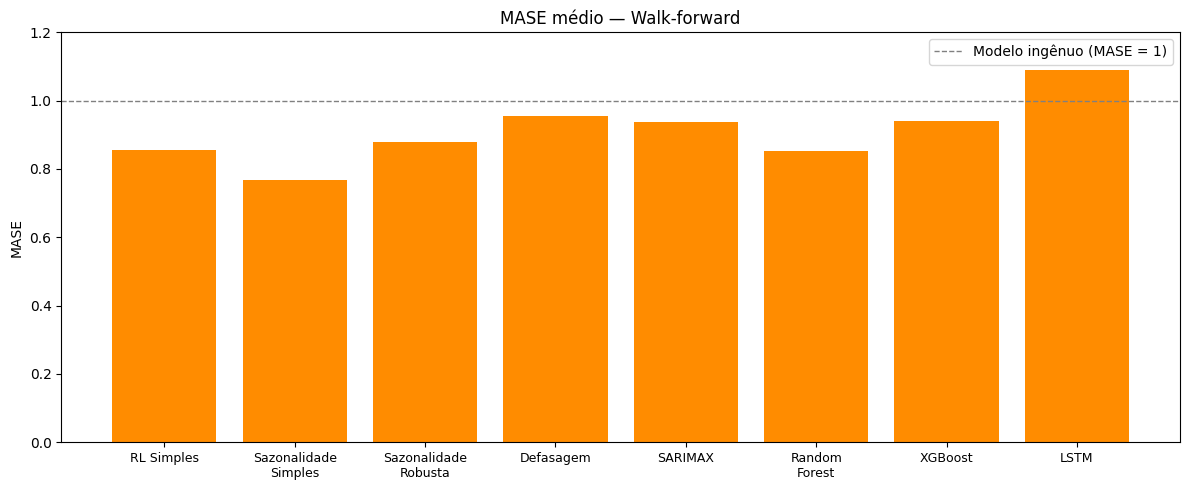

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x, mase, color='darkorange')
ax.axhline(1, color='gray', linestyle='--', linewidth=1, label='Modelo ingênuo (MASE = 1)')

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=9)
ax.set_ylabel('MASE')
ax.set_title('MASE médio — Walk-forward')
ax.set_ylim(0, 1.2)
ax.legend()

plt.tight_layout()
plt.show()



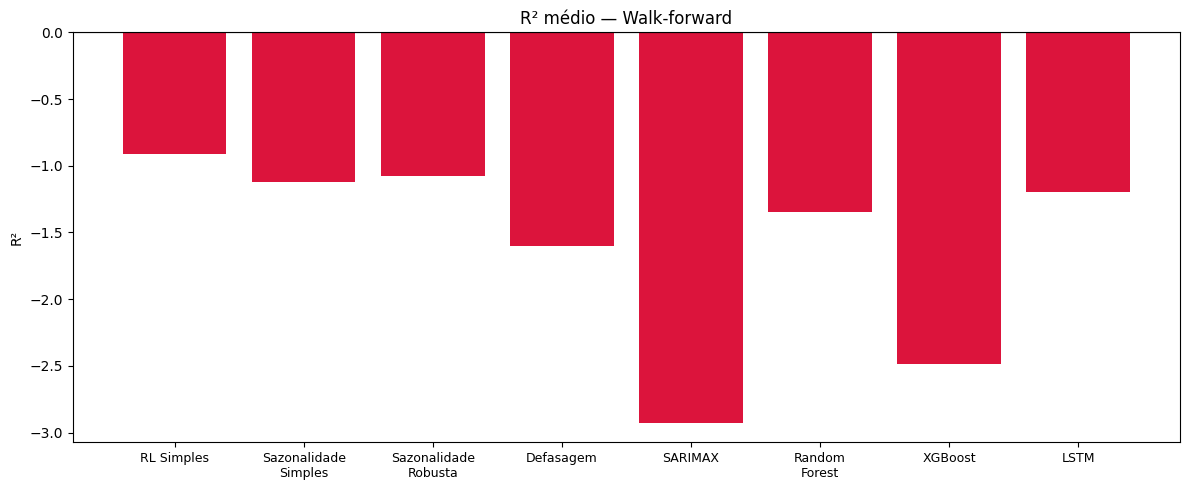

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x, r2, color='crimson')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=9)
ax.set_ylabel('R²')
ax.set_title('R² médio — Walk-forward')

plt.tight_layout()
plt.show()

A avaliação do desempenho preditivo dos modelos foi conduzida por meio de validação walk-forward com dez divisões temporais sucessivas, garantindo que cada modelo fosse treinado exclusivamente com dados anteriores ao período de teste correspondente. Os resultados médios indicam desempenho preditivo limitado para todos os modelos, com R² negativo em todas as classes avaliadas. A sazonalidade simples apresentou o melhor MASE médio, 0,768, seguida pelo Random Forest, 0,853, e pela regressão linear simples, 0,856, todos inferiores a 1, indicando desempenho marginalmente superior ao de um modelo ingênuo de persistência. O Random Forest apresentou o menor RMSE médio, 118,62. Os modelos de defasagem, SARIMAX, XGBoost e LSTM apresentaram MASE superior ou próximo de 1, indicando desempenho equivalente ou inferior ao modelo ingênuo. A análise dos folds individuais revelou desempenho substancialmente pior nos períodos de teste correspondentes à transição para a pandemia.

## Feature Importance

Importância média (Gini) entre os 10 folds:
horas_media      0.226980
salario_media    0.128702
teu_lag3         0.126799
teu_mm6          0.116979
teu_var_pct      0.088672
teu_lag2         0.082837
mês              0.057783
teu              0.038282
teu_mm3          0.038134
teu_mm12         0.034107
teu_lag1         0.026819
trimestre        0.018913
ano              0.011651
covid            0.003340
dtype: float64

Importância média (Permutação) entre os 10 folds:
teu_mm6          0.125586
mês              0.112468
teu_var_pct      0.092317
horas_media      0.045138
teu_mm3          0.033194
teu_lag2         0.024665
salario_media    0.019933
trimestre        0.015153
teu_lag1         0.013540
teu_lag3         0.006305
teu              0.005734
teu_mm12         0.002981
covid            0.000000
ano              0.000000
dtype: float64


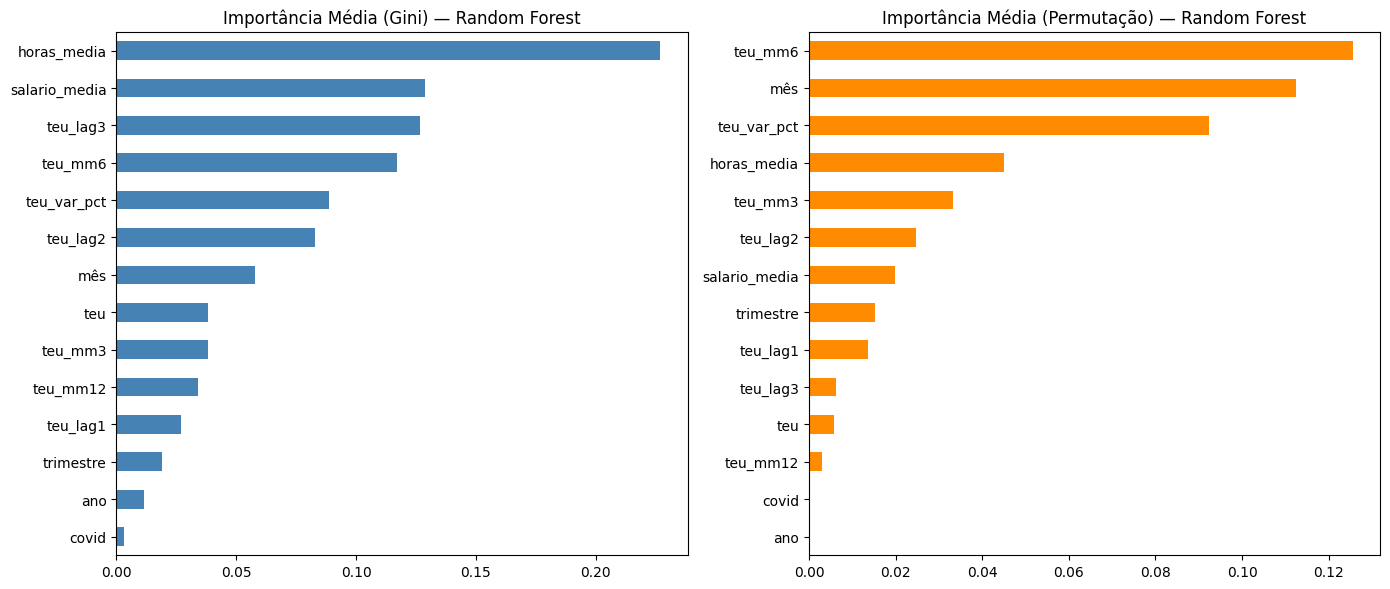

In [ ]:
from sklearn.inspection import permutation_importance

importancias_gini = []
importancias_perm = []

X_full = df_ml[features_ml]
y_full = df_ml['saldo']

for train_idx, test_idx in tscv.split(X_full):
    X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]

    modelo = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=2, random_state=42)
    modelo.fit(X_train, y_train)

    # importância Gini
    importancias_gini.append(modelo.feature_importances_)

    # importância por permutação (avaliada no conjunto de teste)
    perm = permutation_importance(modelo, X_test, y_test, n_repeats=10, random_state=42)
    importancias_perm.append(perm.importances_mean)

gini_medio = pd.Series(np.mean(importancias_gini, axis=0), index=features_ml).sort_values(ascending=False)
perm_medio = pd.Series(np.mean(importancias_perm, axis=0), index=features_ml).sort_values(ascending=False)

print("Importância média (Gini) entre os 10 folds:")
print(gini_medio)

print("\nImportância média (Permutação) entre os 10 folds:")
print(perm_medio)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

gini_medio.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Importância Média (Gini) — Random Forest')
axes[0].invert_yaxis()

perm_medio.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Importância Média (Permutação) — Random Forest')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

A análise de importância de variáveis do Random Forest, calculada tanto pela redução média de impureza quanto por permutação a partir dos modelos treinados em cada fold da validação walk-forward, indicou divergências relevantes entre os dois métodos. Variáveis como horas médias e a defasagem de três meses do TEU apresentaram alta importância pela redução de impureza, porém baixa relevância por permutação, sugerindo ajuste ao conjunto de treinamento sem correspondente capacidade de generalização. A média móvel de seis meses do TEU destacou-se como a variável mais consistente entre os dois métodos, indicando que a tendência recente da movimentação portuária constitui o principal determinante preditivo identificado pelo modelo. A variação percentual mensal do TEU e o mês de referência também apresentaram relevância consistente, este último corroborando o desempenho superior do modelo de sazonalidade simples entre os modelos econométricos. A variável indicadora do período pandêmico não apresentou relevância preditiva no Random Forest.

## Cenários Sintéticos

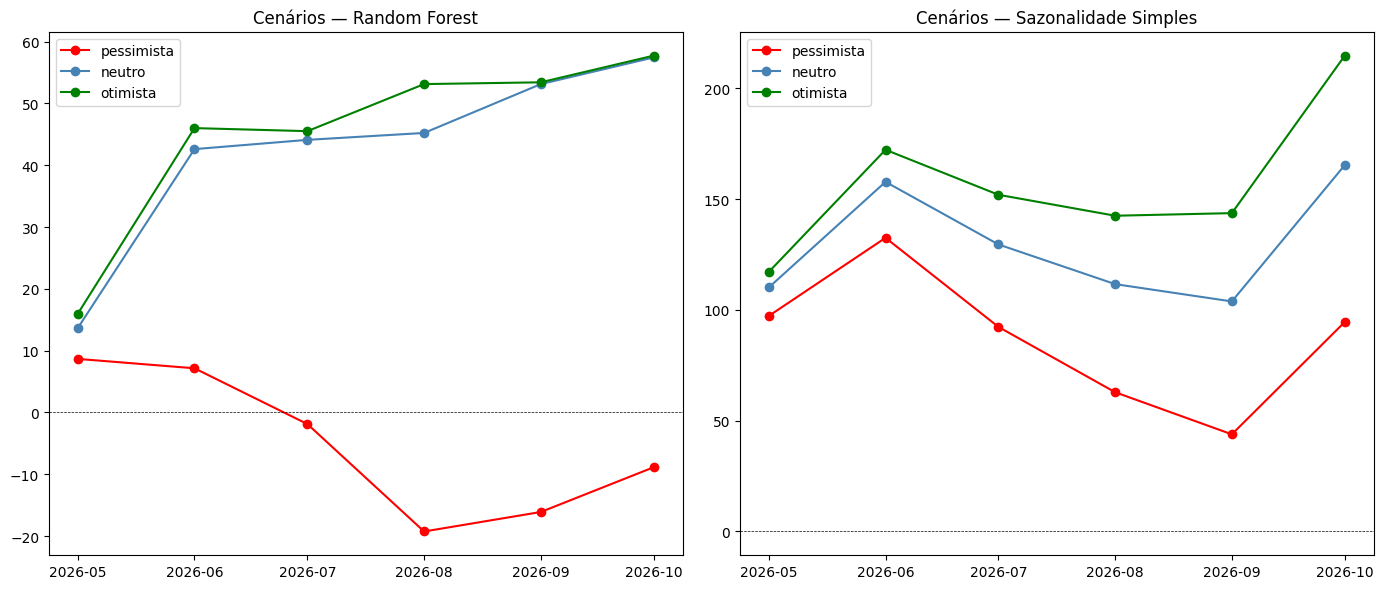


Cenário: pessimista
      data  teu_simulado  saldo_pred_rf  saldo_pred_saz
2026-05-01     114582.35           8.66           97.30
2026-06-01     108853.23           7.15          132.55
2026-07-01     103410.57          -1.88           92.32
2026-08-01      98240.04         -19.26           62.85
2026-09-01      93328.04         -16.11           43.86
2026-10-01      88661.64          -8.86           94.58

Cenário: neutro
      data  teu_simulado  saldo_pred_rf  saldo_pred_saz
2026-05-01     122385.79          13.65          110.15
2026-06-01     124184.64          42.61          157.81
2026-07-01     126009.93          44.11          129.55
2026-08-01     127862.04          45.22          111.64
2026-09-01     129741.38          53.13          103.84
2026-10-01     131648.34          57.44          165.39

Cenário: otimista
      data  teu_simulado  saldo_pred_rf  saldo_pred_saz
2026-05-01     126643.65          15.97          117.17
2026-06-01     132975.83          46.01        

In [ ]:
#Cenários

rf_final = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=2, random_state=42)
rf_final.fit(df_ml[features_ml], df_ml['saldo'])

dummies_cols = [col for col in df_economicos.columns if col.startswith('mês_')]
cols_saz1 = ['teu', 'covid_durante', 'covid_pos'] + dummies_cols
X_saz_final = sm.add_constant(df_economicos[cols_saz1])
y_saz_final = df_economicos['saldo']
saz_final = sm.OLS(y_saz_final, X_saz_final).fit()


ultimo_teu = df['teu'].iloc[-1]
crescimento_medio = df['teu'].pct_change().tail(12).mean()

meses_futuros = pd.date_range(start=df['data'].max() + pd.DateOffset(months=1), periods=6, freq='MS')

cenarios = {
    'pessimista': -0.05,
    'neutro'    : crescimento_medio,
    'otimista'  : 0.05
}

resultados_cenarios = {}

for nome_cenario, taxa in cenarios.items():
    try:
        teu_simulado = [ultimo_teu]
        for _ in range(6):
            teu_simulado.append(teu_simulado[-1] * (1 + taxa))
        teu_simulado = teu_simulado[1:]

        df_cenario = pd.DataFrame({
            'data': meses_futuros,
            'teu': teu_simulado
        })
        df_cenario['mês']       = df_cenario['data'].dt.month
        df_cenario['ano']       = df_cenario['data'].dt.year
        df_cenario['trimestre'] = df_cenario['data'].dt.quarter
        df_cenario['covid']     = 2

        df_cenario['salario_media'] = df['salario_media'].iloc[-1]
        df_cenario['horas_media']   = df['horas_media'].iloc[-1]

        teu_historico = df['teu'].tolist() + teu_simulado

        df_cenario['teu_lag1'] = [teu_historico[len(df) + i - 1] for i in range(6)]
        df_cenario['teu_lag2'] = [teu_historico[len(df) + i - 2] for i in range(6)]
        df_cenario['teu_lag3'] = [teu_historico[len(df) + i - 3] for i in range(6)]

        df_cenario['teu_mm3']  = [np.mean(teu_historico[len(df)+i-3:len(df)+i]) for i in range(6)]
        df_cenario['teu_mm6']  = [np.mean(teu_historico[len(df)+i-6:len(df)+i]) for i in range(6)]
        df_cenario['teu_mm12'] = [np.mean(teu_historico[len(df)+i-12:len(df)+i]) for i in range(6)]

        df_cenario['teu_var_pct'] = [
            (teu_historico[len(df)+i] - teu_historico[len(df)+i-1]) / teu_historico[len(df)+i-1]
            for i in range(6)
        ]

        #Random Forest
        pred_rf = rf_final.predict(df_cenario[features_ml])

        #Sazonalidade Simples
        df_cenario['covid_durante'] = 0
        df_cenario['covid_pos']     = 1

        dummies_cenario = pd.get_dummies(df_cenario['mês'], prefix='mês', drop_first=True).astype(int)
        for col in dummies_cols:
            if col not in dummies_cenario.columns:
                dummies_cenario[col] = 0
        dummies_cenario = dummies_cenario[dummies_cols]  # FORA do for

        X_cenario_saz = pd.concat([
            df_cenario[['teu', 'covid_durante', 'covid_pos']].reset_index(drop=True),
            dummies_cenario.reset_index(drop=True)
        ], axis=1)
        X_cenario_saz = sm.add_constant(X_cenario_saz, has_constant='add')
        X_cenario_saz = X_cenario_saz[X_saz_final.columns]

        pred_saz = saz_final.predict(X_cenario_saz)

        resultados_cenarios[nome_cenario] = pd.DataFrame({
            'data': meses_futuros,
            'teu_simulado': teu_simulado,
            'saldo_pred_rf': pred_rf,
            'saldo_pred_saz': pred_saz.values
        })

    except Exception as e:
        print(f"ERRO no cenário {nome_cenario}: {type(e).__name__}: {e}")

#Visualização

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cores = {'pessimista': 'red', 'neutro': 'steelblue', 'otimista': 'green'}

for nome_cenario, df_resultado in resultados_cenarios.items():
    axes[0].plot(df_resultado['data'], df_resultado['saldo_pred_rf'],
                  label=nome_cenario, color=cores[nome_cenario], marker='o')
    axes[1].plot(df_resultado['data'], df_resultado['saldo_pred_saz'],
                  label=nome_cenario, color=cores[nome_cenario], marker='o')

axes[0].set_title('Cenários — Random Forest')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].legend()

axes[1].set_title('Cenários — Sazonalidade Simples')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].legend()

plt.tight_layout()
plt.show()

for nome_cenario, df_resultado in resultados_cenarios.items():
    print(f"\nCenário: {nome_cenario}")
    print(df_resultado.round(2).to_string(index=False))

A construção de cenários sintéticos para o período de maio a outubro de 2026 permite avaliar a sensibilidade do saldo de empregos a diferentes trajetórias de movimentação portuária, utilizando os modelos Random Forest e Sazonalidade Simples, selecionados como os melhores representantes de aprendizado de máquina e de modelagem econométrica no processo de walk-forward.

No cenário pessimista, com retração mensal de 5% no TEU, o Random Forest projeta uma trajetória decrescente do saldo de empregos, alcançando valores negativos entre agosto e setembro antes de uma leve recuperação em outubro. Já a Sazonalidade Simples mantém previsões positivas durante todo o período, embora em níveis inferiores aos observados nos demais cenários, especialmente nos meses de agosto e setembro, o que reflete o padrão sazonal identificado na análise exploratória.

No cenário neutro, baseado na taxa média de crescimento observada nos últimos doze meses da série, ambos os modelos indicam saldo de empregos positivo e relativamente estável. O Random Forest projeta valores entre 13 e 57 empregos, enquanto a Sazonalidade Simples apresenta previsões entre 104 e 166 empregos, mantendo a tendência observada no walk-forward de gerar valores absolutos mais elevados.

No cenário otimista, com crescimento mensal de 5% no TEU, observa-se a maior expansão do saldo de empregos. O Random Forest atinge seu valor máximo de 57,73 empregos em outubro de 2026, enquanto a Sazonalidade Simples projeta 214,78 empregos no mesmo período, o maior resultado entre todos os cenários analisados.

De forma geral, o Random Forest produz previsões mais conservadoras e de menor amplitude, enquanto a Sazonalidade Simples apresenta respostas mais intensas às variações do TEU. Em ambos os casos, as projeções seguem a direção esperada pela teoria, associando maiores volumes de movimentação portuária a saldos de emprego mais elevados. Contudo, considerando o desempenho preditivo limitado observado no walk-forward, com R² negativo para ambos os modelos, os cenários não devem ser interpretados como previsões pontuais confiáveis.

## Conclusão

O presente trabalho teve como objetivo analisar a relação entre a movimentação de contêineres, mensurada em TEUs, e a demanda por mão de obra formal no setor portuário do município de Santos, por meio da aplicação e comparação de modelos econométricos e de aprendizado de máquina. A abordagem adotada buscou conciliar capacidade preditiva e interpretabilidade, permitindo compreender os fatores associados à dinâmica do emprego portuário.

Os resultados obtidos indicam a existência de uma associação positiva entre a movimentação de TEUs e o saldo de empregos formais, embora de intensidade moderada. A correlação contemporânea observada foi de 0,31, enquanto a maior associação ocorreu com defasagem de dois meses, sugerindo que os efeitos da atividade portuária sobre o mercado de trabalho não se manifestam de forma imediata.

Esse resultado é consistente com a análise de importância das variáveis no modelo Random Forest, na qual a média móvel de seis meses do TEU apresentou maior relevância preditiva do que o volume movimentado no período corrente, evidenciando a importância da trajetória recente da atividade portuária para a explicação do comportamento do emprego.

Entre os modelos econométricos avaliados, a Sazonalidade Simples apresentou o melhor desempenho geral em termos de ajuste, destacando-se pelas métricas calculadas dentro da amostra e reforçando a relevância dos padrões sazonais na dinâmica do emprego portuário, além de evidenciar o impacto significativo do período pandêmico sobre o comportamento da série.

O modelo de Defasagem contribuiu principalmente sob a perspectiva interpretativa, ao identificar um efeito negativo e estatisticamente significativo do salário médio sobre o saldo de empregos, sugerindo que aumentos nos custos de contratação tendem a reduzir a geração líquida de postos de trabalho, independentemente da movimentação de cargas.

No modelo SARIMAX, por sua vez, as variáveis exógenas incluídas não apresentaram significância estatística.

No entanto, quando avaliados sob a perspectiva estritamente preditiva, por meio da validação walk-forward, nenhum dos modelos, econométricos ou de aprendizado de máquina, demonstrou capacidade de generalização satisfatória.
O Random Forest foi o que apresentou os resultados mais consistentes entre os modelos de aprendizado de máquina, obtendo o menor RMSE médio e desempenho marginalmente superior ao modelo ingênuo de referência, com MASE inferior a 1, mas ainda assim com R² negativo fora da amostra.

Os modelos XGBoost e LSTM não conseguiram superar a estratégia de persistência ingênua, e entre os modelos econométricos a capacidade preditiva fora da amostra foi igualmente limitada, mesmo para a Sazonalidade Simples, que se destacara em ajuste dentro da amostra. Esse contraste evidencia que bom ajuste aos dados históricos não se traduziu em capacidade real de previsão para períodos futuros. A validação walk-forward evidenciou uma limitação comum a todas as abordagens analisadas para fins preditivos. Nenhum dos modelos apresentou coeficiente de determinação positivo fora da amostra, indicando dificuldades generalizadas de generalização.

Os períodos de teste que coincidiram com a transição para a pandemia de COVID-19 concentraram os maiores erros preditivos, demonstrando a dificuldade dos modelos em antecipar choques estruturais e eventos sem precedentes a partir de padrões históricos, mas a fragilidade preditiva não se restringiu a esses períodos específicos.

Os cenários prospectivos construídos com base nos modelos de Sazonalidade Simples e Random Forest mostraram que ambas as abordagens respondem de forma coerente, em termos de direção, às variações da movimentação portuária, associando trajetórias mais favoráveis de TEU a saldos de emprego mais elevados. Contudo, dado o desempenho preditivo limitado evidenciado pela validação fora da amostra, esses cenários devem ser interpretados como exercício ilustrativo da elasticidade implícita capturada por cada modelo, e não como previsões pontuais confiáveis para o período projetado.

Entre as principais limitações da pesquisa destacam-se a possibilidade de endogeneidade entre movimentação de TEUs e emprego formal, não tratada explicitamente na modelagem, bem como a presença de quebras estruturais que reduzem a capacidade de generalização preditiva dos modelos ao longo do tempo.

Como perspectivas para trabalhos futuros, recomenda-se a incorporação de métodos capazes de lidar com potenciais relações causais, como modelos com variáveis instrumentais, modelos VAR e testes de causalidade de Granger. Também se sugere a ampliação da série histórica e a utilização de técnicas adicionais de interpretabilidade, como os valores de Shapley, visando aprofundar a compreensão dos fatores que influenciam a dinâmica do emprego portuário.

Em síntese, os resultados demonstram que, embora os modelos econométricos e de aprendizado de máquina forneçam contribuições complementares para a interpretação da relação entre atividade portuária e emprego, identificando relações estruturais como efeitos salariais e padrões sazonais, nenhuma das abordagens demonstrou capacidade preditiva robusta para estimar o saldo de empregos fora da amostra. Essa limitação reforça que a elevada volatilidade do mercado de trabalho portuário e a ocorrência de choques macroeconômicos capazes de alterar substancialmente os padrões históricos observados constituem desafios significativos não apenas para a interpretação, mas, sobretudo, para a aplicação prática desses modelos em contextos preditivos.

